In [35]:
import pandas as pd
import numpy as np

In [36]:
np.random.seed(42)
n = 150
radius = np.random.uniform(50, 500, n)
carriageway_width = np.random.uniform(5.5, 7.5, n)
shoulder_width = np.random.uniform(0.5, 2.5, n)
gradient = np.random.uniform(0, 10, n)
IRI = np.random.uniform(2, 8, n)

shoulder_type = np.random.choice(['paved', 'gravel'], n)
side_friction = np.random.choice(['low', 'medium', 'high'], n)


In [37]:
friction_effect = {'low': 5, 'medium': 0, 'high': -5}
shoulder_effect = {'paved': 2, 'gravel': -2}


In [38]:

speed = (
    80
    - 0.03 * radius
    + 2 * carriageway_width
    - 1.5 * gradient
    - 2 * IRI
    + [friction_effect[f] for f in side_friction]
    + [shoulder_effect[s] for s in shoulder_type]
    + np.random.normal(0, 4, n)
)

In [39]:
data = pd.DataFrame({
    'radius': radius,
    'carriageway_width': carriageway_width,
    'shoulder_width': shoulder_width,
    'gradient': gradient,
    'IRI': IRI,
    'shoulder_type': shoulder_type,
    'side_friction': side_friction,
    'speed': speed
})

data.to_csv(r"D:\Thesis_Speed_Model\data\raw\speed_data_150.csv", index=False)

data.head()

,radius,carriageway_width,shoulder_width,gradient,IRI,shoulder_type,side_friction,speed
0,218.543053,7.316532,0.603363,7.771469,3.013610,paved,high,76.506262
1,477.821438,5.979124,1.562709,5.584042,3.671542,gravel,medium,48.768440
2,379.397274,5.789790,1.581270,4.242220,3.062063,gravel,medium,69.189167
3,319.396318,6.478906,1.774860,9.063544,2.532215,paved,high,65.944675
4,120.208388,7.471301,1.952183,1.111975,2.723815,paved,medium,80.787367


In [40]:
data = pd.read_csv(r"D:\Thesis_Speed_Model\data\raw\speed_data_150.csv")
data.head()

,radius,carriageway_width,shoulder_width,gradient,IRI,shoulder_type,side_friction,speed
0,218.543053,7.316532,0.603363,7.771469,3.013610,paved,high,76.506262
1,477.821438,5.979124,1.562709,5.584042,3.671542,gravel,medium,48.768440
2,379.397274,5.789790,1.581270,4.242220,3.062063,gravel,medium,69.189167
3,319.396318,6.478906,1.774860,9.063544,2.532215,paved,high,65.944675
4,120.208388,7.471301,1.952183,1.111975,2.723815,paved,medium,80.787367


In [41]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   radius             150 non-null    float64
 1   carriageway_width  150 non-null    float64
 2   shoulder_width     150 non-null    float64
 3   gradient           150 non-null    float64
 4   IRI                150 non-null    float64
 5   shoulder_type      150 non-null    str    
 6   side_friction      150 non-null    str    
 7   speed              150 non-null    float64
dtypes: float64(6), str(2)
memory usage: 9.5 KB


In [42]:
data.describe()

,radius,carriageway_width,shoulder_width,gradient,IRI,speed
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,262.799211,6.535044,1.492305,5.255105,4.767227,68.005291
std,133.438848,0.582824,0.602677,3.041343,1.651443,8.111023
min,52.484953,5.510123,0.521675,0.113536,2.120427,48.768440
25%,146.651579,5.994955,0.996718,2.620351,3.299835,62.638228
50%,251.650058,6.612002,1.508389,5.318987,4.612383,67.782326
75%,387.347828,7.015675,2.006255,8.123141,6.085416,73.330523
max,494.099121,7.480108,2.481010,9.997177,7.939761,91.526380


Speed Distribution Plot

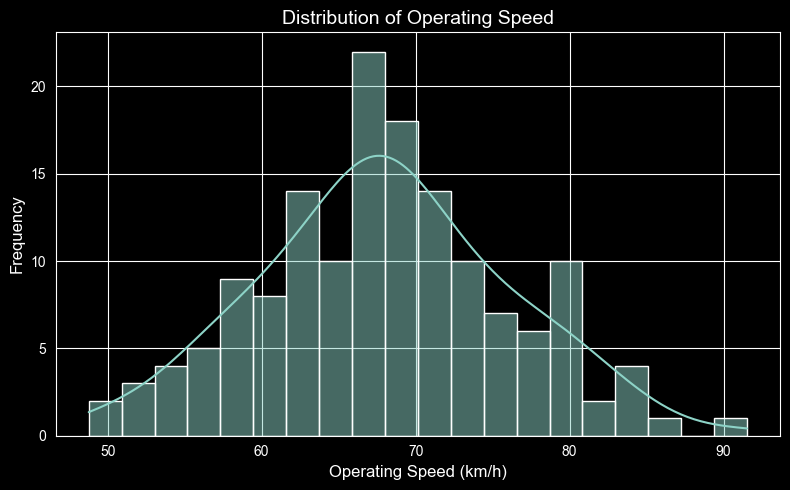

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(data['speed'], bins=20, kde=True)

plt.title("Distribution of Operating Speed", fontsize=14)
plt.xlabel("Operating Speed (km/h)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(True)
plt.tight_layout()

plt.savefig(r"D:\Thesis_Speed_Model\outputs\plots\speed_distribution.png", dpi=300)

plt.show()

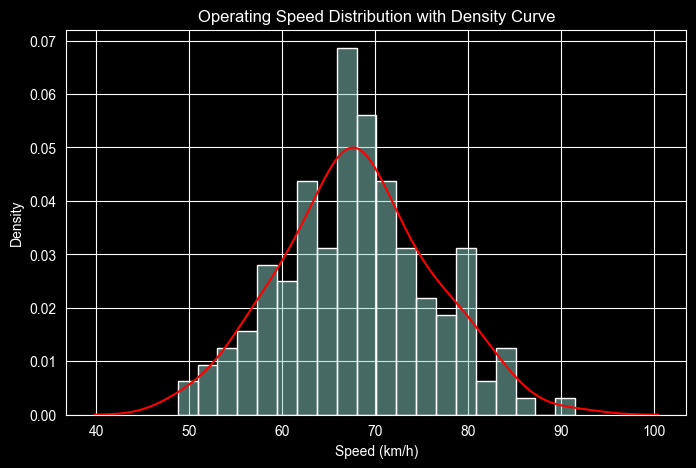

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(data['speed'], bins=20, stat='density', alpha=0.5)
sns.kdeplot(data['speed'], color='red')

plt.title("Operating Speed Distribution with Density Curve")
plt.xlabel("Speed (km/h)")
plt.ylabel("Density")

plt.show()

Correlation Matrix

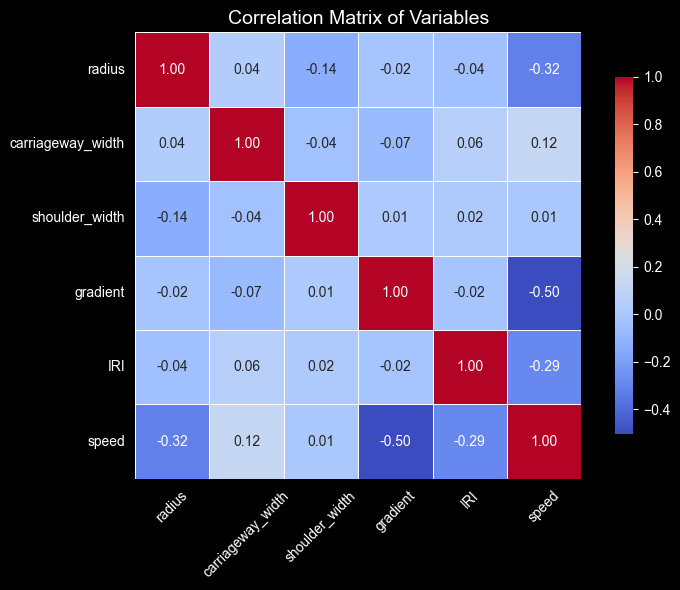

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

corr = data.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Variables", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(r"D:\Thesis_Speed_Model\outputs\plots\correlation_matrix.png", dpi=300)

plt.show()

Relationship Plots

Radius vs Speed

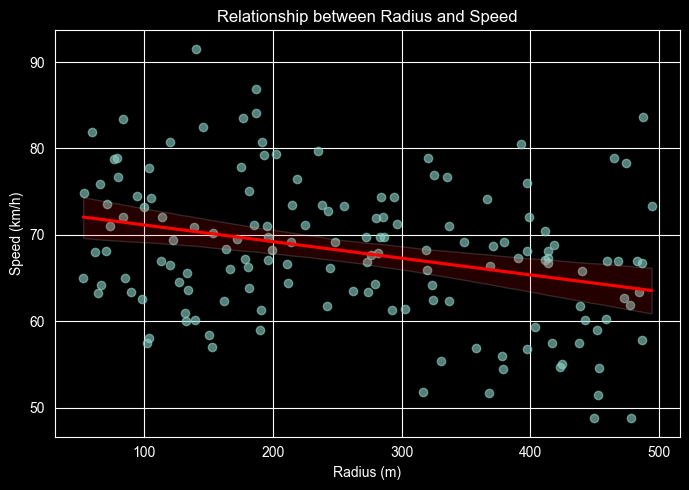

In [46]:
plt.figure(figsize=(7,5))

sns.regplot(
    x='radius',
    y='speed',
    data=data,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title("Relationship between Radius and Speed")
plt.xlabel("Radius (m)")
plt.ylabel("Speed (km/h)")

plt.tight_layout()
plt.savefig(r"D:\Thesis_Speed_Model\outputs\plots\radius_vs_speed.png", dpi=300)

plt.show()

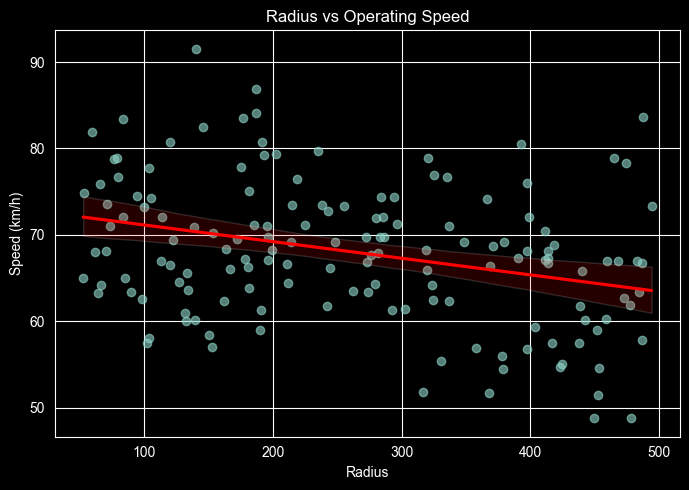

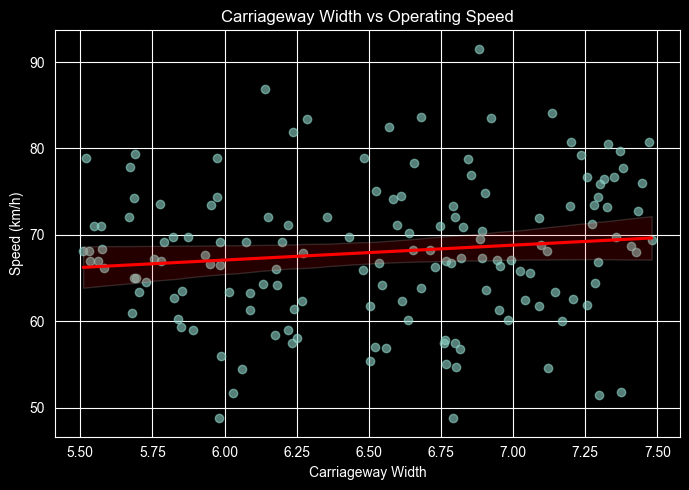

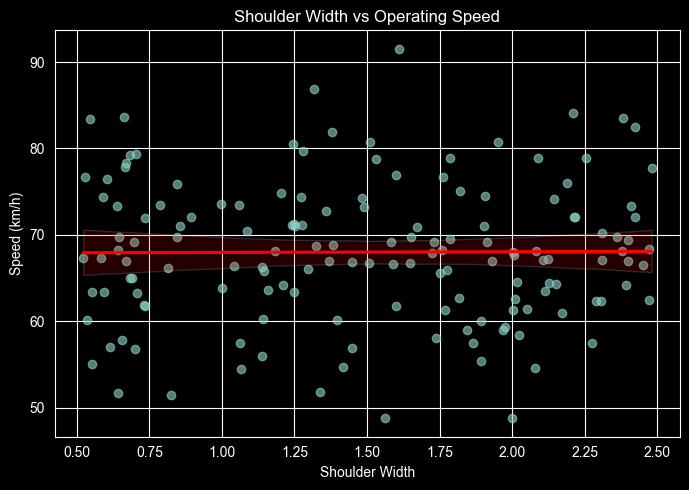

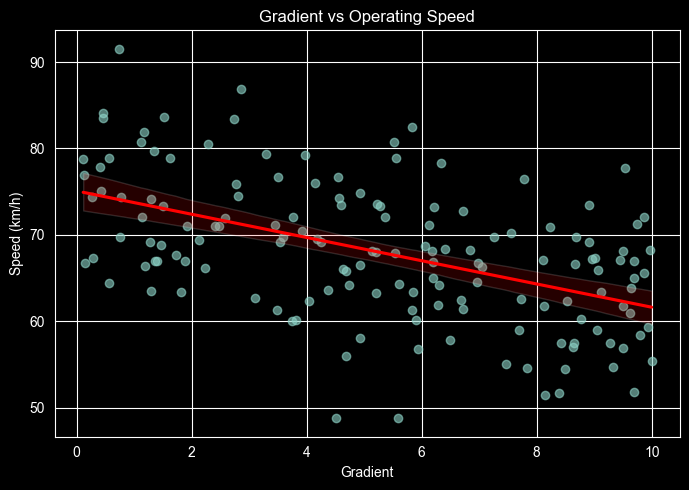

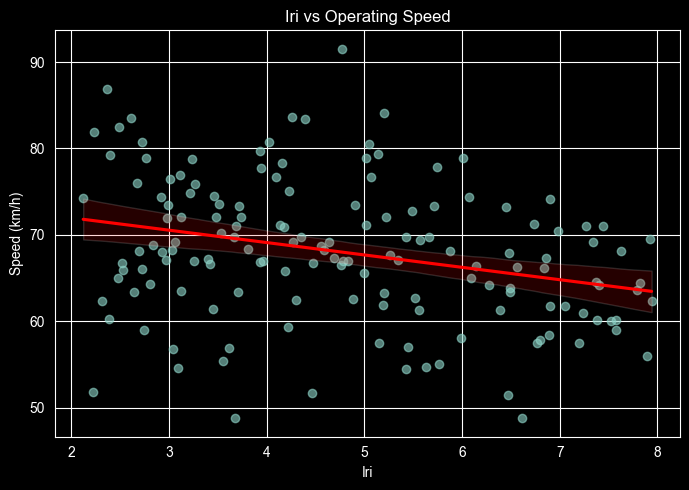

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_vars = [
    'radius',
    'carriageway_width',
    'shoulder_width',
    'gradient',
    'IRI'
]

for var in numerical_vars:
    plt.figure(figsize=(7,5))

    sns.regplot(
        x=var,
        y='speed',
        data=data,
        scatter_kws={'alpha':0.6},
        line_kws={'color':'red'}
    )

    plt.title(f"{var.replace('_',' ').title()} vs Operating Speed")
    plt.xlabel(var.replace('_',' ').title())
    plt.ylabel("Speed (km/h)")

    plt.tight_layout()

    # Save each plot
    plt.savefig(fr"D:\Thesis_Speed_Model\outputs\plots\{var}_vs_speed.png", dpi=300)

    plt.show()

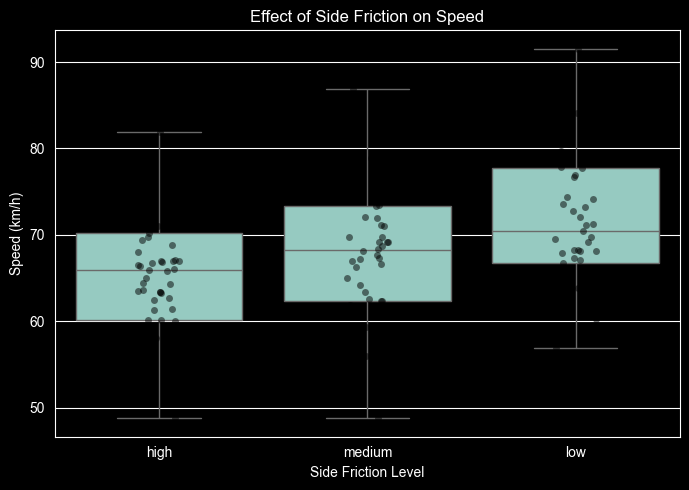

In [48]:
plt.figure(figsize=(7,5))

sns.boxplot(x='side_friction', y='speed', data=data)
sns.stripplot(x='side_friction', y='speed', data=data, color='black', alpha=0.5)

plt.title("Effect of Side Friction on Speed")
plt.xlabel("Side Friction Level")
plt.ylabel("Speed (km/h)")

plt.tight_layout()
plt.savefig(r"D:\Thesis_Speed_Model\outputs\plots\side_friction_vs_speed.png", dpi=300)

plt.show()

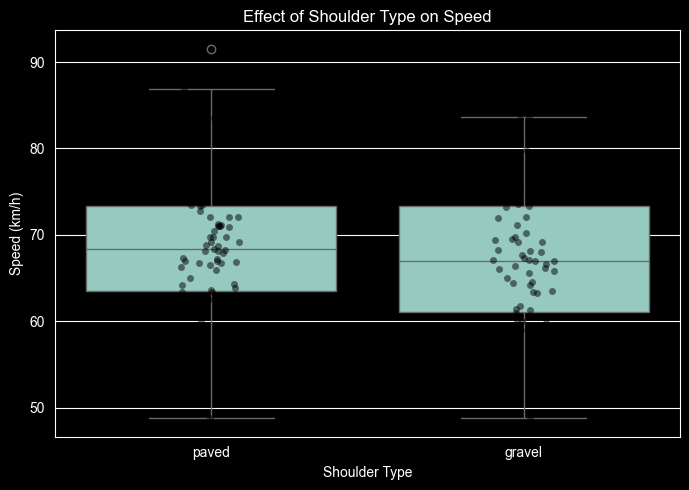

In [49]:
plt.figure(figsize=(7,5))

sns.boxplot(x='shoulder_type', y='speed', data=data)
sns.stripplot(x='shoulder_type', y='speed', data=data, color='black', alpha=0.5)

plt.title("Effect of Shoulder Type on Speed")
plt.xlabel("Shoulder Type")
plt.ylabel("Speed (km/h)")

plt.tight_layout()
plt.savefig(r"D:\Thesis_Speed_Model\outputs\plots\shoulder_type_vs_speed.png", dpi=300)

plt.show()

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Select only numerical independent variables
X = data[['radius', 'carriageway_width', 'shoulder_width', 'gradient', 'IRI']]

# Add constant
X = X.assign(const=1)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data


,Variable,VIF
0,radius,1.021983
1,carriageway_width,1.011287
2,shoulder_width,1.020253
3,gradient,1.006318
4,IRI,1.005842
5,const,152.007839


Encoding


In [51]:
data_encoded = pd.get_dummies(data, drop_first=True)

data_encoded.head()

,radius,carriageway_width,shoulder_width,gradient,IRI,speed,shoulder_type_paved,side_friction_low,side_friction_medium
0,218.543053,7.316532,0.603363,7.771469,3.013610,76.506262,True,False,False
1,477.821438,5.979124,1.562709,5.584042,3.671542,48.768440,False,False,True
2,379.397274,5.789790,1.581270,4.242220,3.062063,69.189167,False,False,True
3,319.396318,6.478906,1.774860,9.063544,2.532215,65.944675,True,False,False
4,120.208388,7.471301,1.952183,1.111975,2.723815,80.787367,True,False,True


MLR Model



Define x and y

In [52]:
X = data_encoded.drop('speed', axis=1)
y = data_encoded['speed']

Train-Test Split

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model

In [54]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Predict

In [55]:
y_pred = model.predict(X_test)

Evaluate Model

In [56]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.7087631470474248
RMSE: 4.618304709869625
MAE: 3.8264255984534103


Actual vs Predicted Plot

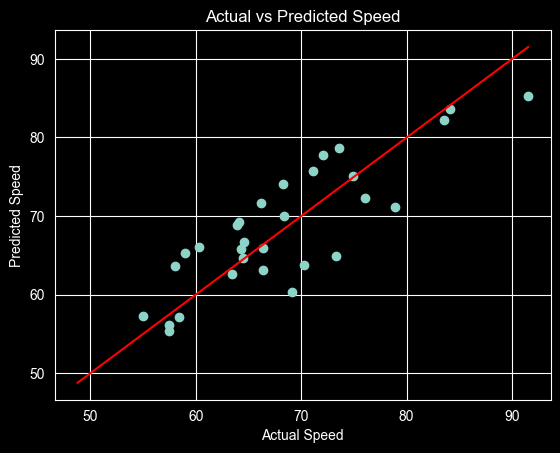

In [57]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("Actual vs Predicted Speed")

# Perfect line
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')

plt.show()

In [58]:
coeff_df = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_
})

coeff_df

,Variable,Coefficient
0,radius,-0.025538
1,carriageway_width,1.532139
2,shoulder_width,-0.608698
3,gradient,-1.361996
4,IRI,-1.940738
5,shoulder_type_paved,3.403510
6,side_friction_low,10.021218
7,side_friction_medium,3.704685


RANDOM FOREST MODEL

In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [60]:
y_pred_rf = rf.predict(X_test)

In [61]:
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("RF R²:", r2_rf)
print("RF RMSE:", rmse_rf)
print("RF MAE:", mae_rf)

RF R²: 0.6190372340251904
RF RMSE: 5.282027824039904
RF MAE: 4.336253649521603


Feature Importance

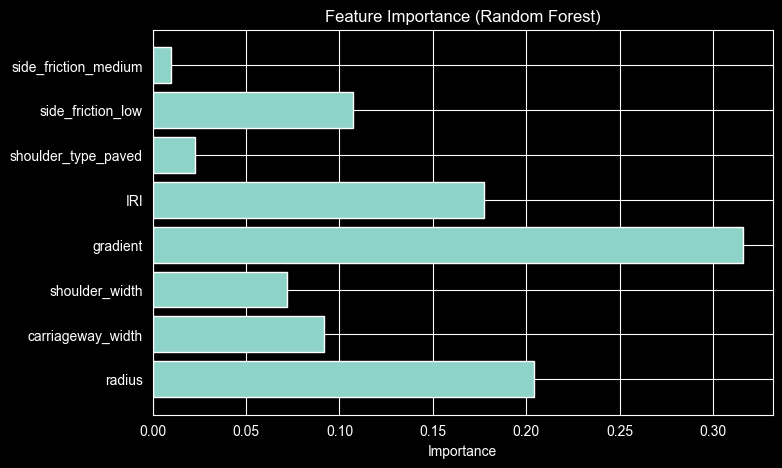

In [62]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

XGBOOST

In [63]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [64]:
y_pred_xgb = xgb.predict(X_test)

In [65]:
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("XGB R²:", r2_xgb)
print("XGB RMSE:", rmse_xgb)
print("XGB MAE:", mae_xgb)

XGB R²: 0.5797855452250694
XGB RMSE: 5.54746936626149
XGB MAE: 4.298515904827846


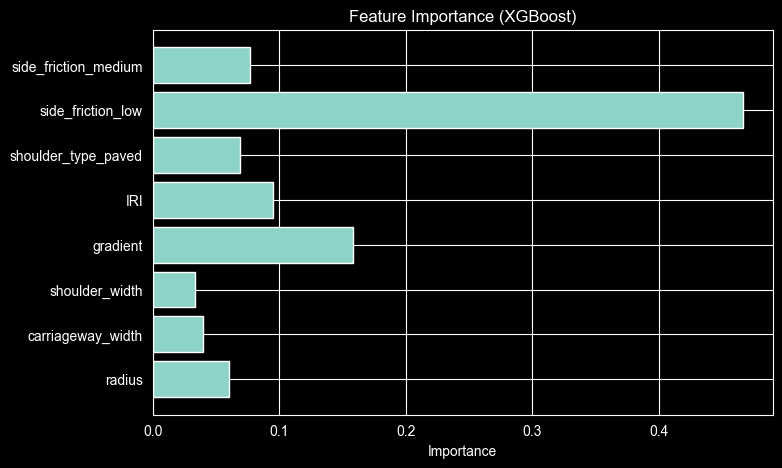

In [66]:
importance = xgb.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

MODEL COMPARISON

In [67]:
results = pd.DataFrame({
    'Model': ['MLR', 'Random Forest', 'XGBoost'],
    'R2': [r2, r2_rf, r2_xgb],
    'RMSE': [rmse, rmse_rf, rmse_xgb],
    'MAE': [mae, mae_rf, mae_xgb]
})

results

,Model,R2,RMSE,MAE
0,MLR,0.708763,4.618305,3.826426
1,Random Forest,0.619037,5.282028,4.336254
2,XGBoost,0.579786,5.547469,4.298516


In [68]:
results.to_csv(r"D:\Thesis_Speed_Model\outputs\tables\model_comparison.csv", index=False)